# Question 1 : Simple Forecast Using Moving Average
Predict the next value using the last 12-month average.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
series = pd.read_csv(url, header=0, parse_dates=['Month'], index_col='Month')

moving_avg = series['Passengers'].rolling(window=12).mean()

forecast = moving_avg.iloc[-1]
print("Forecasted next value:", forecast)

Forecasted next value: 476.1666666666667


# Question 2 : Autocorrelation and Partial Autocorrelation
Plot ACF and PACF to determine seasonality.

<Figure size 1200x500 with 0 Axes>

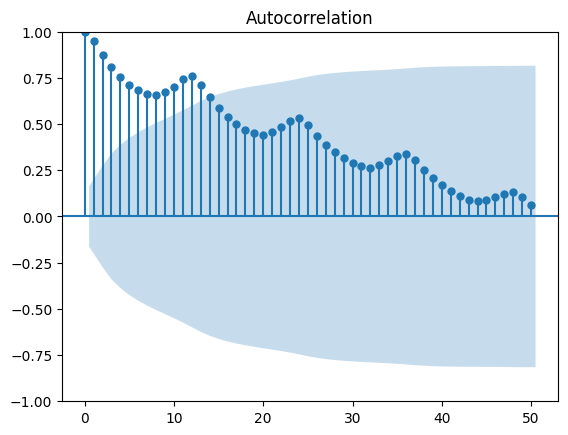

<Figure size 1200x500 with 0 Axes>

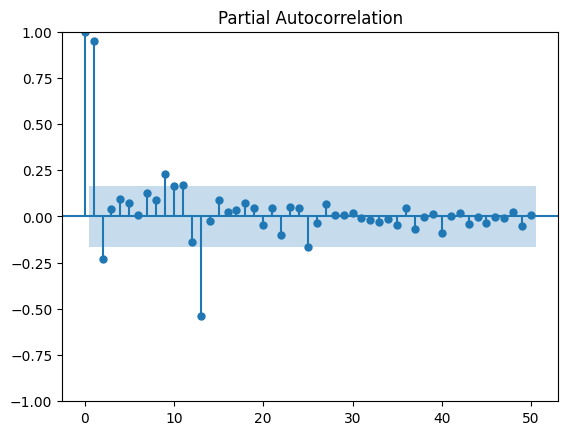

In [2]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plot_acf(series['Passengers'], lags=50)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(series['Passengers'], lags=50)
plt.show()

# Question 3 : Fit ARIMA Model and Forecast
Fit an ARIMA model to the series and forecast the next 12 months.

In [3]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(series['Passengers'], order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)
print(forecast)

C:\Users\kalas\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kalas\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kalas\anaconda3\envs\aiml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


1961-01-01    439.855255
1961-02-01    465.297154
1961-03-01    500.666574
1961-04-01    535.971525
1961-05-01    561.688616
1961-06-01    571.311586
1961-07-01    562.970638
1961-08-01    539.727597
1961-09-01    508.527041
1961-10-01    478.147124
1961-11-01    456.748170
1961-12-01    449.698689
Freq: MS, Name: predicted_mean, dtype: float64


C:\Users\kalas\anaconda3\envs\aiml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Question 4 : Load and Visualize the Dataset
Load the dataset and plot the time series.

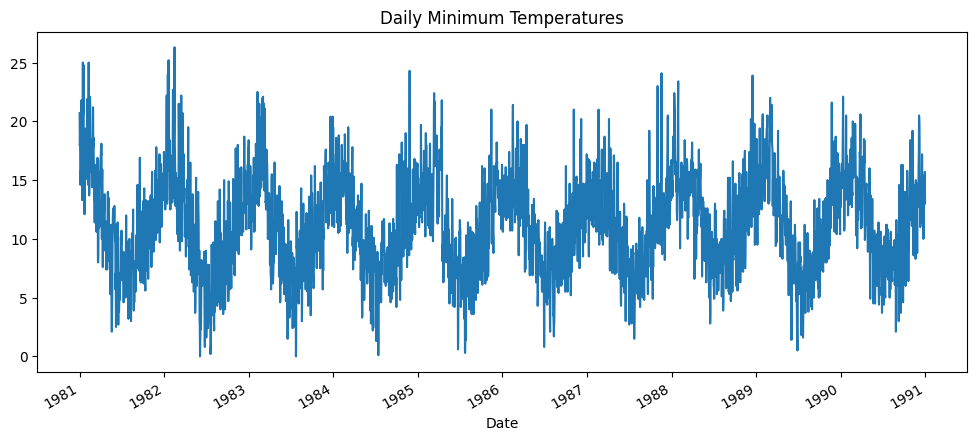

In [4]:
url2 = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
temps = pd.read_csv(url2, header=0, parse_dates=['Date'], index_col='Date')

temps.plot(figsize=(12,5), legend=False, title="Daily Minimum Temperatures")
plt.show()

# Question 5 : Check for Seasonality with Monthly Mean
Calculate the average temperature for each month.

Month
1     15.030323
2     15.373759
3     14.565484
4     12.088333
5      9.866452
6      7.278333
7      6.692581
8      7.891290
9      8.976333
10    10.309355
11    12.479667
12    13.851948
Name: Temp, dtype: float64


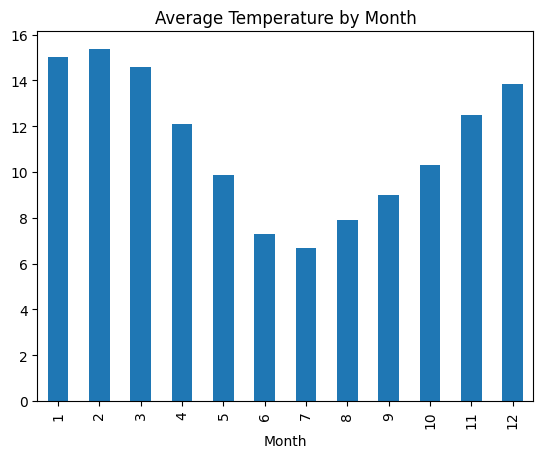

In [5]:
temps['Month'] = temps.index.month
monthly_mean = temps.groupby('Month')['Temp'].mean()

print(monthly_mean)

monthly_mean.plot(kind='bar', title="Average Temperature by Month")
plt.show()